<div style="display: flex; align-items: center; width: 100%;">  
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">    
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>  
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Financial Data Structures
    </h1>
  </div>  
</div>

Calendar-time sampling (one bar per minute/day) draws bars even when nothing is
happening and too few when the market is busy — so time bars have poor
statistical properties. De Prado's *information-driven bars* instead sample
**by activity**: a new bar forms once a fixed amount of ticks, volume, dollar
value, or order-flow imbalance has accumulated.

This notebook builds **every bar type** in `RiskLabAI.Data`:

- **Time bars** (the calendar-time baseline),
- **Standard bars** — tick, volume, dollar,
- **Imbalance bars** — fixed and expected,
- **Run bars** — fixed and expected.

Reference: López de Prado, *Advances in Financial Machine Learning*, Ch. 2.

## 1. Market data

We use a real snapshot of **AAPL 1-minute OHLCV** (with volume) committed to the
repo. Information-driven bars need *volume*, and free programmatic feeds
(Yahoo/Stooq) now rate-limit or block automated downloads — so a committed
snapshot keeps this notebook fully reproducible and offline. To use your own
data, point `csv_path` at any file with `(datetime, price, volume)` columns (e.g.
a live pull, or a WRDS/CRSP export). The bar builders consume any such stream;
we feed each minute's close as one "tick".

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))   # the pinned notebook environment

using RiskLabAI
using CSV, DataFrames, Dates, Statistics, Plots
gr()
theme(:dark)                                      # dark figures (RiskLabAI house style)
default(background_color = :black, background_color_inside = :black)

  Activating project at `C:\arian\risklabai\Notebooks.jl`


In [2]:
csv_path = joinpath(@__DIR__, "..", "AAPL_OHLCV_1m_Data.csv")
raw = CSV.read(csv_path, DataFrame; dateformat = "yyyy-mm-dd HH:MM:SS")
first(raw, 5)

Row,Datetime,Open,High,Low,Close,Volume
,DateTime,Float64,Float64,Float64,Float64,Int64
1,2022-08-22T09:30:00,169.69,169.71,168.93,169.52,3685094
2,2022-08-22T09:31:00,169.52,169.74,169.52,169.7,471038
3,2022-08-22T09:32:00,169.71,169.737,169.26,169.31,352459
4,2022-08-22T09:33:00,169.25,169.25,169.21,169.22,291817
5,2022-08-22T09:34:00,169.25,169.25,168.941,169.04,357077


1949 ticks from 2022-08-22T09:30:00 to 2022-08-26T16:00:00


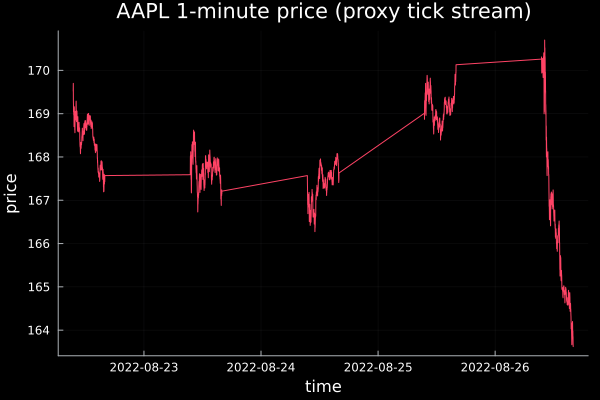

In [3]:
# Columns: Datetime, Open, High, Low, Close, Volume.
ticks = DataFrame(
    date_time = DateTime.(raw.Datetime),
    price = Float64.(raw.Close),
    volume = Float64.(raw.Volume),
)

println("$(nrow(ticks)) ticks from $(ticks.date_time[1]) to $(ticks.date_time[end])")
plot(ticks.date_time, ticks.price; lw = 1, legend = false,
     xlabel = "time", ylabel = "price", title = "AAPL 1-minute price (proxy tick stream)")

## 2. Time bars (the calendar-time baseline)

`TimeBars` samples on a fixed clock. `resolution_type` is one of
`"S"`, `"MIN"`, `"H"`, `"D"`, `"W"`; here, one bar per hour.

In [4]:
time_bars = construct_bars_from_data(
    TimeBars(resolution_type = "H", resolution_units = 1); data = ticks)

# Each bar is a row [date_time, idx, open, high, low, close, volume, …, ticks, dollar].
bars_to_df(bars) = DataFrame(
    date_time = [b[1] for b in bars],
    open  = [Float64(b[3]) for b in bars],
    high  = [Float64(b[4]) for b in bars],
    low   = [Float64(b[5]) for b in bars],
    close = [Float64(b[6]) for b in bars],
    volume = [Float64(b[7]) for b in bars])

println("time bars: ", length(time_bars))
first(bars_to_df(time_bars), 5)

time bars: 

35

Row,date_time,open,high,low,close,volume
,DateTime,Float64,Float64,Float64,Float64,Float64
1,2022-08-22T10:00:00,169.52,169.7,168.56,168.95,1.20818e7
2,2022-08-22T11:00:00,168.855,169.29,168.075,168.075,8.59355e6
3,2022-08-22T12:00:00,168.1,168.84,168.1,168.77,6.73309e6
4,2022-08-22T13:00:00,168.75,169.005,168.615,168.93,5.00843e6
5,2022-08-22T14:00:00,168.86,168.945,168.16,168.2,4.997e6


## 3. Standard bars — tick, volume, dollar

A new bar forms once a fixed number of **ticks**, units of **volume**, or units
of **dollar value** has accumulated. We size each threshold to target roughly
the same number of bars, then compare.

In [5]:
n_target = 50
tick_threshold   = nrow(ticks) / n_target
volume_threshold = sum(ticks.volume) / n_target
dollar_threshold = sum(ticks.price .* ticks.volume) / n_target

tick_bars = construct_bars_from_data(
    StandardBars{Tick}(bar_type = "tick", threshold = tick_threshold); data = ticks)
volume_bars = construct_bars_from_data(
    StandardBars{Volume}(bar_type = "volume", threshold = volume_threshold); data = ticks)
dollar_bars = construct_bars_from_data(
    StandardBars{Dollar}(bar_type = "dollar", threshold = dollar_threshold); data = ticks)

println("tick / volume / dollar bars: ",
        (length(tick_bars), length(volume_bars), length(dollar_bars)))
first(bars_to_df(dollar_bars), 5)

tick / volume / dollar bars: (49, 48, 48)


Row,date_time,open,high,low,close,volume
,DateTime,Float64,Float64,Float64,Float64,Float64
1,2022-08-22T09:35:00,169.52,169.7,169.04,169.04,5.57248e6
2,2022-08-22T09:53:00,169.06,169.16,168.56,168.875,5.27898e6
3,2022-08-22T10:26:00,168.87,169.29,168.595,168.81,5.34679e6
4,2022-08-22T11:04:00,168.93,168.93,168.075,168.336,5.30578e6
5,2022-08-22T11:53:00,168.29,168.81,168.2,168.781,5.27114e6


## 4. Imbalance bars

Imbalance bars sample when the **signed order flow** (via the tick rule) runs
persistently in one direction. The **fixed** variant uses a constant expected bar
size; the **expected** variant re-estimates it online with an EWMA.

In [6]:
init_T = 100   # target ticks per imbalance/run bar
window = 3 * init_T

imbalance_fixed = construct_bars_from_data(
    FixedImbalanceBars{Tick}(bar_type = "tick_imbalance",
        expected_imbalance_window = window,
        initial_estimate_of_expected_n_ticks_in_bar = Float64(init_T)); data = ticks)

imbalance_expected = construct_bars_from_data(
    ExpectedImbalanceBars{Tick}(bar_type = "tick_imbalance",
        window_size_for_expected_n_ticks_estimation = window,
        expected_imbalance_window = window,
        initial_estimate_of_expected_n_ticks_in_bar = Float64(init_T)); data = ticks)

println("imbalance bars (fixed / expected): ",
        (length(imbalance_fixed), length(imbalance_expected)))

imbalance bars (fixed / expected): 

(87, 7)


## 5. Run bars

Run bars sample on the length of the **longest run** of same-signed ticks,
again in fixed and expected forms.

In [7]:
run_fixed = construct_bars_from_data(
    FixedRunBars{Tick}(bar_type = "tick_run",
        expected_imbalance_window = window,
        initial_estimate_of_expected_n_ticks_in_bar = Float64(init_T)); data = ticks)

run_expected = construct_bars_from_data(
    ExpectedRunBars{Tick}(bar_type = "tick_run",
        window_size_for_expected_n_ticks_estimation = window,
        expected_imbalance_window = window,
        initial_estimate_of_expected_n_ticks_in_bar = Float64(init_T)); data = ticks)

println("run bars (fixed / expected): ", (length(run_fixed), length(run_expected)))

run bars (fixed / expected): 

(19, 10)


## 6. How the schemes compare

The bar count per scheme, and *when* each scheme samples. Activity-driven bars
(dollar) cluster their samples during volatile, high-volume periods — exactly
where calendar-time bars under-sample.

In [8]:
summary = DataFrame(
    method = ["Time (hourly)", "Tick", "Volume", "Dollar",
              "Imbalance (fixed)", "Imbalance (expected)",
              "Run (fixed)", "Run (expected)"],
    n_bars = [length(time_bars), length(tick_bars), length(volume_bars), length(dollar_bars),
              length(imbalance_fixed), length(imbalance_expected),
              length(run_fixed), length(run_expected)])
show(summary; allrows = true)

8×2 DataFrame
 Row │ method                n_bars 
     │ String                Int64  
─────┼──────────────────────────────
   1 │ Time (hourly)             35
   2 │ Tick                      49
   3 │ Volume                    48
   4 │ Dollar                    48
   5 │ Imbalance (fixed)         87
   6 │ Imbalance (expected)       7
   7 │ Run (fixed)               19
   8 │ Run (expected)            10

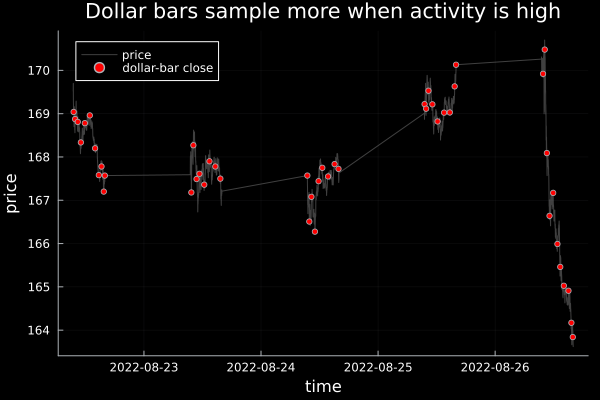

In [9]:
bar_times(bars)  = [b[1] for b in bars]
bar_closes(bars) = [Float64(b[6]) for b in bars]

plot(ticks.date_time, ticks.price; lw = 1, c = :gray, alpha = 0.5, label = "price",
     legend = :topleft, xlabel = "time", ylabel = "price",
     title = "Dollar bars sample more when activity is high")
scatter!(bar_times(dollar_bars), bar_closes(dollar_bars); ms = 3, c = :red,
         label = "dollar-bar close")

## Takeaways

- **Time bars** sample on the clock, regardless of activity.
- **Tick / volume / dollar** bars sample on accumulated activity; **dollar bars**
  are usually the most statistically well-behaved.
- **Imbalance** and **run** bars sample on *order-flow direction*; each comes in
  **fixed** and online-**expected** forms.

Every constructor — `TimeBars`, `StandardBars{Tick|Volume|Dollar}`,
`{Fixed,Expected}ImbalanceBars`, `{Fixed,Expected}RunBars` — and
`construct_bars_from_data` come from `RiskLabAI.Data`.